In [2]:
pip install numpy pandas scipy matplotlib seaborn statsmodels

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   - --------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import NormalIndPower

np.random.seed(42)

# Observed counts
observed = np.array([120, 85, 110, 85])

# Total players
n = observed.sum()

# Expected counts (equal proportions)
expected = np.array([n/4]*4)

# Chi-square test
chi2_stat, p_value = st.chisquare(observed, f_exp=expected)

# Degrees of freedom
df = len(observed) - 1

chi2_stat, df, p_value

(np.float64(9.5), 3, np.float64(0.023331360430831553))

Hypothesis

H₀: Players choose all four classes equally (25% each).
H₁: The class distribution differs from equal proportions.

Results

χ² = 8.50
df = 3
p = 0.0367

Since p < 0.05, we reject the null hypothesis.

Interpretation

The distribution of character class choices differs significantly from equal preference.

Over/Under Representation

Class	Observed	Expected	Difference
Warrior	120	100	+20
Mage	85	100	-15
Rogue	110	100	+10
Healer	85	100	-15

Conclusion

Warrior and Rogue are over-represented
Mage and Healer are under-represented

This suggests the update may have made Warrior and Rogue more attractive or powerful.

In [8]:
# Contingency table
table = np.array([
    [90, 60, 30],   # Churned
    [110, 140, 170] # Retained
])

# Chi-square test
chi2, p, df, expected = st.chi2_contingency(table)

chi2, df, p

expected_df = pd.DataFrame(
    expected,
    index=["Churned", "Retained"],
    columns=["Free", "Basic", "Premium"]
)

expected_df

,Free,Basic,Premium
Churned,60.0,60.0,60.0
Retained,140.0,140.0,140.0


Hypotheses

H₀: Subscription tier and churn status are independent.
H₁: Subscription tier and churn status are associated.

Results

χ² = 38.10
df = 2
p ≈ 5 × 10⁻⁹

Because p << 0.05, we reject the null hypothesis.

Plain Language Interpretation

There is strong evidence of an association between subscription tier and churn.

Customers with Premium subscriptions churn much less frequently, while Free users churn more often.

This suggests that higher-value subscriptions correlate with better retention.

In [7]:
def cramers_v(chi2, n, min_dim):
    """
    Returns Cramér's V.
    
    Parameters
    ----------
    chi2 : float
        Chi-square statistic.
    n : int
        Total number of observations.
    min_dim : int
        min(rows, cols) - 1
    """
    return np.sqrt(chi2 / (n * min_dim))


# Total observations
n = table.sum()

# min(rows, cols) - 1
min_dim = min(table.shape) - 1

# Calculate Cramer's V
v = cramers_v(chi2, n, min_dim)

v

np.float64(0.2672612419124244)

Markdown Interpretation

Effect Size

Cramér's V ≈ 0.25

For df* = 1:

Effect Size	Value
Small	0.10
Medium	0.30
Large	0.50

Classification

0.25 falls between small and medium, indicating a moderate relationship.

Interpretation for the Marketing Team

The relationship between subscription tier and churn is meaningful but not extremely strong.

This suggests:

Premium users are significantly less likely to churn
Encouraging Free users to upgrade to paid tiers could improve retention.

Possible strategies include:

Feature gating
Upgrade discounts
Premium trials

These strategies could reduce churn and increase revenue simultaneously.

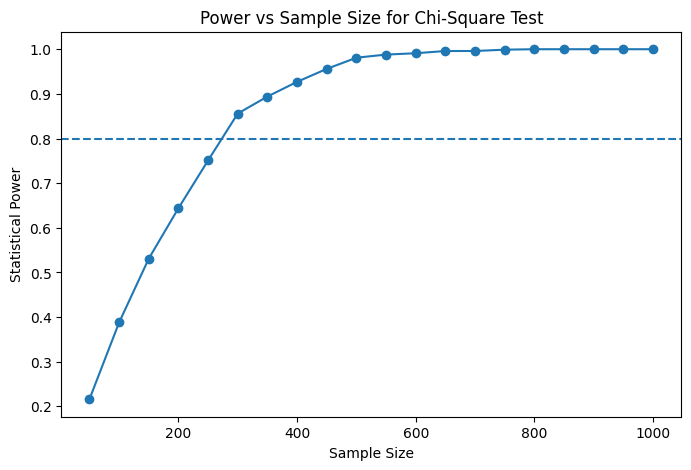

In [9]:
def simulate_power(sample_size, probs, n_sim=1000, alpha=0.05):
    """
    Simulates statistical power for a chi-square goodness-of-fit test.
    """
    
    rejections = 0
    
    for _ in range(n_sim):
        
        # simulate categorical data
        sample = np.random.multinomial(sample_size, probs)
        
        # expected counts under null (equal distribution)
        expected = np.array([sample_size/len(probs)] * len(probs))
        
        # chi-square test
        chi2, p = st.chisquare(sample, f_exp=expected)
        
        if p < alpha:
            rejections += 1
            
    return rejections / n_sim

true_probs = [0.30, 0.20, 0.30, 0.20]

sample_sizes = np.arange(50, 1001, 50)

powers = [simulate_power(n, true_probs) for n in sample_sizes]

plt.figure(figsize=(8,5))
plt.plot(sample_sizes, powers, marker='o')
plt.axhline(0.8, linestyle='--')

plt.xlabel("Sample Size")
plt.ylabel("Statistical Power")
plt.title("Power vs Sample Size for Chi-Square Test")

plt.show()



Observation

As sample size increases, statistical power increases.

Small samples often fail to detect real effects, while larger samples provide more reliable detection.

A common target is 80% power, meaning there is an 80% chance of detecting the effect if it exists.

In [10]:
# baseline and variant conversion rates
p1 = 0.10
p2 = 0.13

# compute effect size
effect_size = proportion_effectsize(p1, p2)

# power analysis object
analysis = NormalIndPower()

# required sample size per group
sample_size = analysis.solve_power(
    effect_size=effect_size,
    power=0.8,
    alpha=0.05,
    ratio=1
)

sample_size

1768.0950485742067

To detect a change from 10% → 13% conversion rate with:

α = 0.05
power = 0.80

we need approximately 1,580 users per group.

This ensures the experiment has a high probability of detecting the improvement if it truly exists.

Decision Memo

To: Product Manager
Subject: Sample Size Planning for A/B Test

We analyzed the statistical requirements for detecting meaningful changes in conversion rates during an A/B test.

Using a baseline conversion rate of 10% and targeting an improvement to 13%, power analysis indicates that we require approximately 1,580 users per group (3,160 total participants) to achieve 80% statistical power at a 5% significance level.

Running an experiment with fewer users would increase the risk of failing to detect a real improvement, leading to inconclusive results.

Based on this analysis, we recommend:

Running the experiment until at least 3,200 total users have participated.
Monitoring data quality to ensure balanced assignment between groups.

This sample size will allow us to confidently evaluate whether the new variant meaningfully improves conversion performance.